# Combining & organizing data

## Libraries and settings

In [72]:
# Libraries
import os
import pandas as pd
import numpy as np
import fnmatch

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Show current working directory
print(os.getcwd())

/workspaces/data_analytics_Fadri/Week_03


## Importing the prepared rental apartments data

In [73]:
# Read data to pandas data frame
df_orig = pd.read_csv('apartments_data_prepared.csv', 
                      sep=',', 
                      encoding='utf-8')

# Copy of data with selected colums
columns = [ 'web-scraper-order', 
            'address_raw',
            'rooms', 
            'area', 
            'luxurious',
            'price',
            'price_per_m2']
df = df_orig[columns]

# Get number of rows and columns
print(df.shape)

# Show first records
df.head(5)

(865, 7)


,web-scraper-order,address_raw,rooms,area,luxurious,price,price_per_m2
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49.0,0,1441.0,29.41
1,1693998201-2,"Zürcherstrasse 1, 8173 Neerach, ZH",3.5,65.0,0,1850.0,28.46
2,1693998201-4,"Cramerstrasse 8-12, 8004 Zürich, ZH",2.0,54.0,0,4853.0,89.87
3,1693998201-5,"Rotachstrasse 33, 8003 Zürich, ZH",2.0,49.0,0,4335.0,88.47
4,1693998201-16,"Wolframplatz 1, 8045 Zürich, ZH",2.0,32.0,0,3515.0,109.84


## Combining data from different sources

### Reading rental apartment data with geocoded addresses

In [74]:
# Meaning of variables
# lat: geographical latitude
# lon: geographical longitude
# bfs_number: official municipality id
# bfs_name: official municipality name

# Geocoded data (i.e. data with latitude and longitude)
df_geo = pd.read_csv('apartments_data_geocoded.csv', 
                     sep=',', 
                     encoding='utf-8')

# Rename columns
df_geo = df_geo.rename(columns={'web-scrape':'web-scraper-order',
                                'address_ra':'address_raw',
                                'BFS_NUMMER':'bfs_number', 
                                'NAME':'bfs_name'})

# Show data
df_geo[['web-scraper-order',
        'address_raw',
        'lat', 
        'lon', 
        'bfs_number', 
        'bfs_name']].head()

,web-scraper-order,address_raw,lat,lon,bfs_number,bfs_name
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",47.252171,8.845797,118,Rüti (ZH)
1,1693998201-2,"Zürcherstrasse 1, 8173 Neerach, ZH",47.513332,8.474851,88,Neerach
2,1693998201-5,"Rotachstrasse 33, 8003 Zürich, ZH",47.370792,8.514748,261,Zürich
3,1693998201-16,"Wolframplatz 1, 8045 Zürich, ZH",47.362282,8.522193,261,Zürich
4,1693998205-25,"Badenerstrasse 67, 8953 Dietikon, ZH",47.407925,8.392561,243,Dietikon


### Join geo-information to rental apartment data using .merge()

In [75]:
df2 = df.merge(df_geo[['web-scraper-order', 
                       'lat', 
                       'lon', 
                       'bfs_number', 
                       'bfs_name']], 
               on="web-scraper-order")
df2.head()

,web-scraper-order,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49.0,0,1441.0,29.41,47.252171,8.845797,118,Rüti (ZH)
1,1693998201-2,"Zürcherstrasse 1, 8173 Neerach, ZH",3.5,65.0,0,1850.0,28.46,47.513332,8.474851,88,Neerach
2,1693998201-5,"Rotachstrasse 33, 8003 Zürich, ZH",2.0,49.0,0,4335.0,88.47,47.370792,8.514748,261,Zürich
3,1693998201-16,"Wolframplatz 1, 8045 Zürich, ZH",2.0,32.0,0,3515.0,109.84,47.362282,8.522193,261,Zürich
4,1693998205-25,"Badenerstrasse 67, 8953 Dietikon, ZH",3.5,105.0,0,3200.0,30.48,47.407925,8.392561,243,Dietikon


### Reading municipality-level data

In [76]:
# Meaning of variables:
# bfs_number: official municipality id
# bfs_name: official municipality name
# pop: number of residents (=population)
# pop_dens: population density (pop per km2)
# frg_pct: percentage foreigners
# emp: numer of employees

df_municip = pd.read_excel('municipality_data.xlsx', 
                           sheet_name='data_for_import')
df_municip.head(5)

,bfs_number,bfs_name,pop,pop_dens,frg_pct,emp,mean_taxable_income
0,1,Aeugst am Albis,1981,250.442478,14.184755,442.0,105013.570634
1,2,Affoltern am Albis,12303,1161.756374,28.700317,6920.0,71059.805603
2,3,Bonstetten,5572,749.932705,16.564968,1014.0,88927.698145
3,4,Hausen am Albis,3751,275.808824,16.022394,1021.0,86300.455137
4,5,Hedingen,3778,578.560490,16.410799,1478.0,90811.205330


### Join municipality data to rental apartment data using .merge()

In [77]:
# Merge needs a key which must be identical in both data sets (here the key is 'bfs_number')
df3 = df2.merge(df_municip[['bfs_number', 
                            'pop', 
                            'pop_dens', 
                            'frg_pct', 
                            'emp']], 
                on="bfs_number")
df3.head(5)

,web-scraper-order,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name,pop,pop_dens,frg_pct,emp
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49.0,0,1441.0,29.41,47.252171,8.845797,118,Rüti (ZH),12286,1221.272366,24.841283,5053.0
1,1693998201-2,"Zürcherstrasse 1, 8173 Neerach, ZH",3.5,65.0,0,1850.0,28.46,47.513332,8.474851,88,Neerach,3175,525.662252,13.322835,641.0
2,1693998201-5,"Rotachstrasse 33, 8003 Zürich, ZH",2.0,49.0,0,4335.0,88.47,47.370792,8.514748,261,Zürich,420217,4778.994655,32.458468,491193.0
3,1693998201-16,"Wolframplatz 1, 8045 Zürich, ZH",2.0,32.0,0,3515.0,109.84,47.362282,8.522193,261,Zürich,420217,4778.994655,32.458468,491193.0
4,1693998205-25,"Badenerstrasse 67, 8953 Dietikon, ZH",3.5,105.0,0,3200.0,30.48,47.407925,8.392561,243,Dietikon,27746,2970.663812,46.226483,18911.0


### Join Aufgabe 2.i und j

In [78]:
# Merge der Apartmentdaten mit den Gemeindedaten, einschließlich 'mean_taxable_income'
df3 = df2.merge(df_municip[['bfs_number', 'mean_taxable_income']], on='bfs_number')

# Ausgabe des zusammengeführten DataFrames
df3.head(5)

,web-scraper-order,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name,mean_taxable_income
0,1693998201-1,"Neuhusstrasse 6, 8630 Rüti ZH, ZH",3.0,49.0,0,1441.0,29.41,47.252171,8.845797,118,Rüti (ZH),65362.042683
1,1693998201-2,"Zürcherstrasse 1, 8173 Neerach, ZH",3.5,65.0,0,1850.0,28.46,47.513332,8.474851,88,Neerach,111422.358722
2,1693998201-5,"Rotachstrasse 33, 8003 Zürich, ZH",2.0,49.0,0,4335.0,88.47,47.370792,8.514748,261,Zürich,82932.737704
3,1693998201-16,"Wolframplatz 1, 8045 Zürich, ZH",2.0,32.0,0,3515.0,109.84,47.362282,8.522193,261,Zürich,82932.737704
4,1693998205-25,"Badenerstrasse 67, 8953 Dietikon, ZH",3.5,105.0,0,3200.0,30.48,47.407925,8.392561,243,Dietikon,64662.737784


### Export data to file

In [79]:
# Remove missing values which may have ocured from the merging process
df3 = df3.dropna()

# Check for missing values per column
print(df3.isna().sum())

# Count number of rows and columns
print(df3.shape)

# Export apartment data to file
df3.to_csv('apartments_data_enriched.csv',
            sep=',',
            encoding='utf-8')

web-scraper-order      0
address_raw            0
rooms                  0
area                   0
luxurious              0
price                  0
price_per_m2           0
lat                    0
lon                    0
bfs_number             0
bfs_name               0
mean_taxable_income    0
dtype: int64
(790, 12)


### Sorting data

In [80]:
# Sorting data by 'price' and 'area' with highest price above (ascending=False)
df3.sort_values(by=['price', 'area'], 
                ascending=False).head()

,web-scraper-order,address_raw,rooms,area,luxurious,price,price_per_m2,lat,lon,bfs_number,bfs_name,mean_taxable_income
261,1693998265-365,"Gustav-Gull-Platz 4, 8004 Zürich, ZH",4.5,140.0,0,9950.0,71.07,47.379471,8.531120,261,Zürich,82932.737704
262,1693998265-366,"Engweg 8, 8006 Zürich, ZH",4.5,140.0,0,9170.0,65.50,47.385265,8.537632,261,Zürich,82932.737704
145,1693998236-207,"Etzelstrasse 35, 8038 Zürich, ZH",3.5,100.0,1,9150.0,91.50,47.346546,8.530695,261,Zürich,82932.737704
136,1693998236-197,"Utoquai 37, 8008 Zürich, ZH",3.5,169.0,0,9000.0,53.25,47.363682,8.546781,261,Zürich,82932.737704
346,1693998285-475,"Universitätstrasse 41, 8006 Zürich, ZH",4.5,140.0,0,8990.0,64.21,47.380440,8.547943,261,Zürich,82932.737704


### Aggregation of data

In [81]:
# Aggregation using .groupby()
df3[['rooms', 'price']].groupby(['rooms']).mean()

,price
rooms,
1.0,1306.346154
1.5,2110.166667
2.0,2155.846154
2.5,2423.468085
3.0,1955.600000
3.5,2699.044335
4.0,2852.357143
4.5,3076.186747
5.0,2881.666667


## Reshaping data

### Reshaping data using .stack() and .unstack()

In [82]:
df_sub = df3[['bfs_name', 'rooms', 'price', 'area']][:5]
print('Original shape')
print(df_sub, '\n')

df_sub_stacked = df_sub.stack()
print('Stacked')
print(df_sub_stacked, '\n')

# Using unstack
print('Unstacked (= back to original shape)')
print(df_sub_stacked.unstack())

Original shape
    bfs_name  rooms   price   area
0  Rüti (ZH)    3.0  1441.0   49.0
1    Neerach    3.5  1850.0   65.0
2     Zürich    2.0  4335.0   49.0
3     Zürich    2.0  3515.0   32.0
4   Dietikon    3.5  3200.0  105.0 

Stacked
0  bfs_name    Rüti (ZH)
   rooms             3.0
   price          1441.0
   area             49.0
1  bfs_name      Neerach
   rooms             3.5
   price          1850.0
   area             65.0
2  bfs_name       Zürich
   rooms             2.0
   price          4335.0
   area             49.0
3  bfs_name       Zürich
   rooms             2.0
   price          3515.0
   area             32.0
4  bfs_name     Dietikon
   rooms             3.5
   price          3200.0
   area            105.0
dtype: object 

Unstacked (= back to original shape)
    bfs_name rooms   price   area
0  Rüti (ZH)   3.0  1441.0   49.0
1    Neerach   3.5  1850.0   65.0
2     Zürich   2.0  4335.0   49.0
3     Zürich   2.0  3515.0   32.0
4   Dietikon   3.5  3200.0  105.0


### Reshaping data using .melt()

In [83]:
df_sub = df3[['rooms', 'price', 'area']][:5]
print('Original shape')
print(df_sub, '\n')

print('Reshaped using .melt()')
print(pd.melt(df, id_vars=['rooms'], value_vars=['price', 'area']))

Original shape
   rooms   price   area
0    3.0  1441.0   49.0
1    3.5  1850.0   65.0
2    2.0  4335.0   49.0
3    2.0  3515.0   32.0
4    3.5  3200.0  105.0 

Reshaped using .melt()
      rooms variable   value
0       3.0    price  1441.0
1       3.5    price  1850.0
2       2.0    price  4853.0
3       2.0    price  4335.0
4       2.0    price  3515.0
...     ...      ...     ...
1725    3.5     area    82.0
1726    4.0     area    73.0
1727    4.5     area   110.0
1728    3.0     area    68.0
1729    4.5     area   114.0

[1730 rows x 3 columns]


### Pivoting data using .pivot_table()

In [84]:
# Using pivot_table to reshape the data and calculate means
pd.pivot_table(df3[['rooms', 'price', 'area']],
               index=['rooms'],
               values=['price', 'area', 'rooms'],
               aggfunc=(np.mean))

# Aufgaben
pd.pivot_table(df3[['price', 'price_per_m2']],
               index='price',
               values=['price', 'price_per_m2'],
               aggfunc=(np.mean))

# Ausgabe der Pivot-Tabelle
print(df3)

    web-scraper-order                                 address_raw  rooms  \
0        1693998201-1           Neuhusstrasse 6, 8630 Rüti ZH, ZH    3.0   
1        1693998201-2          Zürcherstrasse 1, 8173 Neerach, ZH    3.5   
2        1693998201-5           Rotachstrasse 33, 8003 Zürich, ZH    2.0   
3       1693998201-16             Wolframplatz 1, 8045 Zürich, ZH    2.0   
4       1693998205-25        Badenerstrasse 67, 8953 Dietikon, ZH    3.5   
..                ...                                         ...    ...   
813   1693998381-1001  Murzlenstrasse 66, 8166 Niederweningen, ZH    4.5   
814   1693998381-1002               Bungert 6, 8909 Zwillikon, ZH    2.5   
815   1693998381-1003         Ebnetstrasse 6, 8406 Winterthur, ZH    1.5   
816   1693998381-1004        Hölderlinstrasse 12, 8032 Zürich, ZH    3.5   
819   1693998381-1008           Maneggstrasse 83, 8041 Zürich, ZH    4.5   

      area  luxurious   price  price_per_m2        lat       lon  bfs_number  \
0     4

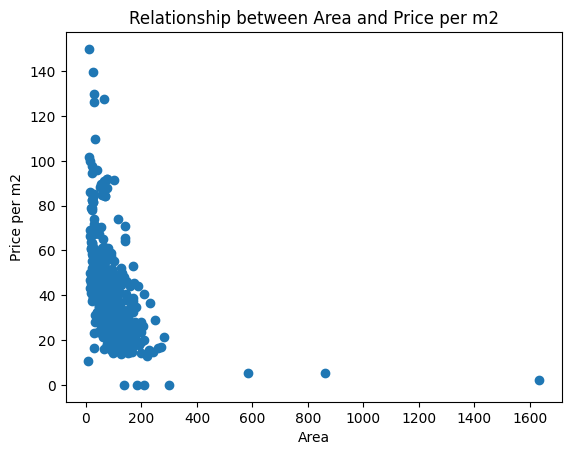

In [85]:
#Aufgabe e
# Beziehung zwischen area und price_per_m2 untersuchen
import matplotlib.pyplot as plt

plt.scatter(df['area'], df['price_per_m2'])
plt.xlabel('Area')
plt.ylabel('Price per m2')
plt.title('Relationship between Area and Price per m2')
plt.show()

# Erklärung:
# Es gibt oft eine inverse Beziehung zwischen der Fläche und dem Preis pro Quadratmeter.
# Größere Wohnungen haben tendenziell einen niedrigeren Preis pro Quadratmeter, während kleinere Wohnungen einen höheren Preis pro Quadratmeter haben.

In [86]:
# Aufgabe f
pivot_table_count = pd.pivot_table(df3[['rooms', 'price', 'area']],
                                   index=['rooms'],
                                   values=['price'],
                                   aggfunc='count')

# Ausgabe der Pivot-Tabelle mit count
print(pivot_table_count)


       price
rooms       
1.0       52
1.5       36
2.0       39
2.5      141
3.0       45
3.5      203
4.0       28
4.5      166
5.0        3
5.5       54
6.0        3
6.5       14
7.0        2
7.5        3
8.5        1


In [87]:
# Aufgabe g
# Pivot-Tabelle mit Mittelwerten von rooms, area, price und price_per_m2 pro Gemeinde
pivot_table_mean = pd.pivot_table(df3[['rooms', 'area', 'price', 'price_per_m2']],
                                  index='rooms', 
                                  aggfunc='mean')

# Sortieren der Pivot-Tabelle nach price und area
pivot_table_mean_sorted = pivot_table_mean.sort_values(
    by=['price', 'area'], ascending=[False, False])

# Ausgabe der sortierten Pivot-Tabelle
print(pivot_table_mean_sorted)

             area        price  price_per_m2
rooms                                       
8.5    210.000000  8500.000000     40.480000
7.0    175.000000  6350.000000     36.325000
7.5    205.000000  4765.000000     23.273333
6.0    667.666667  3833.333333     15.706667
6.5    256.357143  3787.000000     20.130714
5.5    153.685185  3537.777778     23.258519
4.5    114.969880  3076.186747     26.425904
5.0    108.000000  2881.666667     26.376667
4.0     98.464286  2852.357143     29.646429
3.5     89.945813  2699.044335     29.942956
2.5     67.028369  2423.468085     37.391631
2.0     54.589744  2155.846154     42.528462
1.5     35.333333  2110.166667     65.455000
3.0     68.800000  1955.600000     28.403778
1.0     32.057692  1306.346154     50.168077


### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [88]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.5.0-1025-azure
Datetime: 2024-10-08 10:10:03
Python Version: 3.11.10
-----------------------------------
